# Lung Cancer Prediction — Revision V2

This notebook replaces the original leakage-prone lung-cancer experiment with a reviewer-ready, leakage-free evaluation.

## Corrections implemented
- The **original 309-record dataset is split first** using a stratified 80/20 train–test split.
- No duplicated observation is created before the split.
- Missing-value imputation, scaling, and random oversampling are performed **inside training folds only**.
- The untouched test set is never oversampled, used for tuning, or used for threshold selection.
- `classification_report(y_test, y_pred)` is used in the correct order.
- ROC–AUC and PR–AUC are calculated from **predicted probabilities**, not hard labels.
- Five boosting models are tuned using stratified cross-validation on training data only.
- Probability calibration is performed using training data only.
- A decision threshold is selected from **out-of-fold training probabilities** using Youden's J statistic and then locked.
- Results are reported at both the default 0.50 threshold and the training-derived threshold.
- Accuracy, balanced accuracy, precision, sensitivity, specificity, F1, ROC–AUC, PR–AUC, Brier score, confusion matrices, and bootstrap 95% CIs are produced.
- Repeated stratified CV scores are exported for statistical testing.
- SHAP and LIME are regenerated from the corrected leakage-free model.
- SHAP/LIME outputs are interpreted as explanations of **model behavior**, not causal clinical effects.

> **Important:** The lung-cancer dataset is small and highly imbalanced (309 observations).  
> The revised analysis therefore emphasizes uncertainty, class-specific performance, calibration, and confidence intervals rather than accuracy alone.


In [1]:
# Optional installation if required
# !pip install -q imbalanced-learn xgboost lightgbm catboost shap lime

import warnings, time, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    GridSearchCV, cross_validate, cross_val_predict
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, balanced_accuracy_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load and minimally encode the original lung-cancer dataset

This uses the same raw dataset as the original repository: `Lung Cancer Dataset (1).csv`.

Only label conversion required to represent categorical text numerically is performed at this stage. No resampling, scaling, imputation fitting, or model-related transformation occurs before the train–test split.


In [2]:
DATA_PATH = "Lung Cancer Dataset (1).csv"
TARGET = "LC"

data = pd.read_csv(DATA_PATH).copy()
data.columns = [c.strip() for c in data.columns]

print("Original shape:", data.shape)
print("Columns:", list(data.columns))
display(data.head())

# Encode Gender only if stored as text.
if data["GD"].dtype == "object":
    gd_map = {v: i for i, v in enumerate(sorted(data["GD"].dropna().unique()))}
    data["GD"] = data["GD"].map(gd_map)
    print("Gender encoding:", gd_map)

# Encode outcome robustly if it is stored as text.
if data[TARGET].dtype == "object":
    raw_classes = list(data[TARGET].dropna().unique())
    print("Raw target classes:", raw_classes)

    # Prefer LC/YES/TRUE as positive class where possible.
    normalized = data[TARGET].astype(str).str.strip().str.upper()
    positive_tokens = {"YES", "Y", "TRUE", "1", "LC", "LUNG CANCER", "POSITIVE"}

    if normalized.isin(positive_tokens).any():
        data[TARGET] = normalized.isin(positive_tokens).astype(int)
    else:
        le = LabelEncoder()
        data[TARGET] = le.fit_transform(data[TARGET].astype(str))
        print("Fallback target classes:", dict(zip(le.classes_, le.transform(le.classes_))))

data[TARGET] = data[TARGET].astype(int)

print("\nEncoded target distribution:")
print(data[TARGET].value_counts().sort_index())


Original shape: (309, 16)
Columns: ['GD', 'AG', 'SM', 'YF', 'AN', 'PP', 'CD', 'FT', 'AL', 'WH', 'AC', 'CF', 'SB', 'SD', 'CP', 'LC']


,GD,AG,SM,YF,AN,PP,CD,FT,AL,WH,AC,CF,SB,SD,CP,LC
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


Gender encoding: {'F': 0, 'M': 1}
Raw target classes: ['YES', 'NO']

Encoded target distribution:
LC
0     39
1    270
Name: count, dtype: int64


## 2. Split first — the critical leakage safeguard

The raw dataset is divided into stratified 80% training and 20% test subsets **before oversampling or any fitted preprocessing**.


In [3]:
X = data.drop(columns=[TARGET]).copy()
y = data[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nUntouched test class distribution:")
print(y_test.value_counts().sort_index())

assert len(X_train) + len(X_test) == len(data)
assert set(X_train.index).isdisjoint(set(X_test.index))

print("\nLeakage safeguard passed: original train/test row indices do not overlap.")


Training shape: (247, 15)
Test shape: (62, 15)

Training class distribution:
LC
0     31
1    216
Name: count, dtype: int64

Untouched test class distribution:
LC
0     8
1    54
Name: count, dtype: int64

Leakage safeguard passed: original train/test row indices do not overlap.


## 3. Leakage-free preprocessing and resampling

The original repository used `sklearn.utils.resample(..., replace=True)`, i.e. random duplication rather than SMOTE.  
The corrected experiment therefore uses `RandomOverSampler` **inside an imbalanced-learn pipeline**, preserving the original resampling concept while preventing duplicated rows from entering validation or test sets.

No global outlier clipping is performed. Age values are retained as observed because the submitted methodology states that clinically plausible extremes are not removed by default.


In [4]:
def make_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
        ("oversampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", model),
    ])

models_and_grids = {
    "XGBoost": (
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        {
            "model__n_estimators": [200, 500, 800],
            "model__learning_rate": [0.02, 0.05, 0.10],
            "model__max_depth": [2, 3, 5],
            "model__min_child_weight": [1, 3],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
        }
    ),

    "CatBoost": (
        CatBoostClassifier(
            verbose=0,
            random_seed=RANDOM_STATE
        ),
        {
            "model__iterations": [200, 500, 800],
            "model__learning_rate": [0.02, 0.05, 0.10],
            "model__depth": [3, 5, 7],
            "model__l2_leaf_reg": [3, 7, 12],
        }
    ),

    "LightGBM": (
        LGBMClassifier(
            boosting_type="gbdt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        ),
        {
            "model__n_estimators": [200, 500, 800],
            "model__learning_rate": [0.02, 0.05, 0.10],
            "model__max_depth": [2, 3, 5],
            "model__num_leaves": [7, 15, 31],
            "model__min_child_samples": [10, 20, 30],
        }
    ),

    "AdaBoost": (
        AdaBoostClassifier(random_state=RANDOM_STATE),
        {
            "model__n_estimators": [100, 300, 500],
            "model__learning_rate": [0.02, 0.05, 0.10, 0.50],
        }
    ),

    "GradientBoosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            "model__n_estimators": [100, 300, 500],
            "model__learning_rate": [0.02, 0.05, 0.10],
            "model__max_depth": [1, 2, 3],
            "model__min_samples_leaf": [1, 3, 5],
            "model__subsample": [0.8, 1.0],
        }
    ),
}


## 4. Hyperparameter optimization on training data only

Because the positive lung-cancer class is the majority class in this benchmark dataset, **balanced accuracy** is used as the primary tuning criterion rather than raw accuracy. This prevents the search from favoring majority-class predictions.

Five-fold stratified cross-validation is used consistently for all five models.


In [5]:
inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

best_estimators = {}
search_objects = {}
tuning_rows = []

for name, (model, grid) in models_and_grids.items():
    print(f"\nTuning {name} ...")

    search = GridSearchCV(
        estimator=make_pipeline(model),
        param_grid=grid,
        scoring="balanced_accuracy",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        return_train_score=False
    )

    t0 = time.perf_counter()
    search.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0

    best_estimators[name] = search.best_estimator_
    search_objects[name] = search

    tuning_rows.append({
        "Model": name,
        "Best_CV_Balanced_Accuracy": search.best_score_,
        "Tuning_Time_sec": elapsed,
        "Best_Params": json.dumps(
            {k.replace("model__", ""): v for k, v in search.best_params_.items()}
        )
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values(
    "Best_CV_Balanced_Accuracy", ascending=False
)

display(tuning_df)
tuning_df.to_csv("LC_V2_hyperparameters.csv", index=False)



Tuning XGBoost ...

Tuning CatBoost ...

Tuning LightGBM ...

Tuning AdaBoost ...

Tuning GradientBoosting ...


,Model,Best_CV_Balanced_Accuracy,Tuning_Time_sec,Best_Params
4,GradientBoosting,0.832598,6.229822,"{""learning_rate"": 0.1, ""max_depth"": 1, ""min_sa..."
0,XGBoost,0.808074,4.404772,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.1..."
2,LightGBM,0.802930,92.302130,"{""learning_rate"": 0.1, ""max_depth"": 3, ""min_ch..."
1,CatBoost,0.798331,21.639470,"{""depth"": 3, ""iterations"": 800, ""l2_leaf_reg"":..."
3,AdaBoost,0.780819,1.311888,"{""learning_rate"": 0.02, ""n_estimators"": 300}"


## 5. Training-only probability calibration

Sigmoid/Platt calibration is fitted using training data only. Three-fold calibration is used because the minority no-lung-cancer class is small.


In [6]:
calibration_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

calibrated_models = {}

for name, estimator in best_estimators.items():
    calibrated = CalibratedClassifierCV(
        estimator=clone(estimator),
        method="sigmoid",
        cv=calibration_cv
    )
    calibrated.fit(X_train, y_train)
    calibrated_models[name] = calibrated

print("Calibrated models:", list(calibrated_models))


Calibrated models: ['XGBoost', 'CatBoost', 'LightGBM', 'AdaBoost', 'GradientBoosting']


## 6. Training-only threshold selection

The decision threshold is selected from **out-of-fold calibrated probabilities generated only from the training set**.  
Youden's J statistic is used to balance sensitivity and specificity.

The threshold is then locked before the held-out test set is examined.


In [7]:
def choose_youden_threshold(y_true, prob):
    fpr, tpr, thresholds = roc_curve(y_true, prob)
    valid = np.isfinite(thresholds)
    fpr = fpr[valid]
    tpr = tpr[valid]
    thresholds = thresholds[valid]
    j = tpr - fpr
    return float(thresholds[np.argmax(j)])

threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE + 101
)

locked_thresholds = {}
oof_probabilities = {}
threshold_rows = []

for name, estimator in best_estimators.items():
    print("Generating training-only OOF probabilities:", name)

    calibrator_for_oof = CalibratedClassifierCV(
        estimator=clone(estimator),
        method="sigmoid",
        cv=3
    )

    oof_prob = cross_val_predict(
        calibrator_for_oof,
        X_train, y_train,
        cv=threshold_cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    threshold = choose_youden_threshold(y_train.to_numpy(), oof_prob)
    pred_oof = (oof_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train, pred_oof, labels=[0,1]
    ).ravel()

    locked_thresholds[name] = threshold
    oof_probabilities[name] = oof_prob

    threshold_rows.append({
        "Model": name,
        "Locked_Threshold": threshold,
        "OOF_Accuracy": accuracy_score(y_train, pred_oof),
        "OOF_Balanced_Accuracy": balanced_accuracy_score(y_train, pred_oof),
        "OOF_Precision": precision_score(y_train, pred_oof, zero_division=0),
        "OOF_Sensitivity": recall_score(y_train, pred_oof, zero_division=0),
        "OOF_Specificity": tn/(tn+fp),
        "OOF_F1": f1_score(y_train, pred_oof, zero_division=0),
        "OOF_ROC_AUC": roc_auc_score(y_train, oof_prob),
        "OOF_PR_AUC": average_precision_score(y_train, oof_prob),
        "OOF_Brier": brier_score_loss(y_train, oof_prob)
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values(
    ["OOF_Balanced_Accuracy", "OOF_ROC_AUC"],
    ascending=False
)

display(threshold_df)
threshold_df.to_csv("LC_V2_training_only_thresholds.csv", index=False)


Generating training-only OOF probabilities: XGBoost
Generating training-only OOF probabilities: CatBoost
Generating training-only OOF probabilities: LightGBM
Generating training-only OOF probabilities: AdaBoost
Generating training-only OOF probabilities: GradientBoosting


,Model,Locked_Threshold,OOF_Accuracy,OOF_Balanced_Accuracy,OOF_Precision,OOF_Sensitivity,OOF_Specificity,OOF_F1,OOF_ROC_AUC,OOF_PR_AUC,OOF_Brier
1,CatBoost,0.898483,0.882591,0.891428,0.984456,0.879630,0.903226,0.929095,0.909349,0.979899,0.072824
0,XGBoost,0.910300,0.854251,0.889038,0.989130,0.842593,0.935484,0.910000,0.910394,0.983400,0.070393
2,LightGBM,0.914760,0.846154,0.870594,0.983696,0.837963,0.903226,0.905000,0.895311,0.977358,0.075268
4,GradientBoosting,0.856087,0.829960,0.861335,0.983333,0.819444,0.903226,0.893939,0.931601,0.989816,0.071523
3,AdaBoost,0.900072,0.732794,0.833408,0.993421,0.699074,0.967742,0.820652,0.909872,0.986304,0.074885


## 7. Final evaluation on the untouched test set

For this dataset:
- **Sensitivity** = proportion of actual lung-cancer cases correctly identified.
- **Specificity** = proportion of actual non-lung-cancer cases correctly identified.

Because the test set contains only a small number of negative cases, specificity and its confidence interval should be interpreted cautiously.


In [8]:
def metric_bundle(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0,1]
    ).ravel()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": tn/(tn+fp) if (tn+fp) else np.nan,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "Brier": brier_score_loss(y_true, y_prob),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }

test_rows = []
prediction_store = {}

for name, model in calibrated_models.items():
    prob = model.predict_proba(X_test)[:,1]

    pred_default = (prob >= 0.50).astype(int)
    pred_locked = (prob >= locked_thresholds[name]).astype(int)

    default_metrics = metric_bundle(y_test, pred_default, prob)
    locked_metrics = metric_bundle(y_test, pred_locked, prob)

    prediction_store[name] = {
        "prob": prob,
        "pred_default": pred_default,
        "pred_locked": pred_locked
    }

    test_rows.append({
        "Model": name,
        "Threshold_Type": "Default_0.50",
        "Threshold": 0.50,
        **default_metrics
    })

    test_rows.append({
        "Model": name,
        "Threshold_Type": "Training_Optimized",
        "Threshold": locked_thresholds[name],
        **locked_metrics
    })

test_results_df = pd.DataFrame(test_rows)
display(test_results_df)

test_results_df.to_csv(
    "LC_V2_test_results_default_and_optimized.csv",
    index=False
)


,Model,Threshold_Type,Threshold,Accuracy,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC,Brier,TN,FP,FN,TP
0,XGBoost,Default_0.50,0.500000,0.870968,0.712963,0.925926,0.925926,0.500,0.925926,0.937500,0.990765,0.073712,4,4,4,50
1,XGBoost,Training_Optimized,0.910300,0.822581,0.898148,1.000000,0.796296,1.000,0.886598,0.937500,0.990765,0.073712,8,0,11,43
2,CatBoost,Default_0.50,0.500000,0.903226,0.731481,0.928571,0.962963,0.500,0.945455,0.962963,0.994729,0.059324,4,4,2,52
3,CatBoost,Training_Optimized,0.898483,0.870968,0.925926,1.000000,0.851852,1.000,0.920000,0.962963,0.994729,0.059324,8,0,8,46
4,LightGBM,Default_0.50,0.500000,0.919355,0.793981,0.945455,0.962963,0.625,0.954128,0.960648,0.994336,0.061206,5,3,2,52
5,LightGBM,Training_Optimized,0.914760,0.854839,0.916667,1.000000,0.833333,1.000,0.909091,0.960648,0.994336,0.061206,8,0,9,45
6,AdaBoost,Default_0.50,0.500000,0.903226,0.678241,0.913793,0.981481,0.375,0.946429,0.931713,0.989670,0.076607,3,5,1,53
7,AdaBoost,Training_Optimized,0.900072,0.725806,0.842593,1.000000,0.685185,1.000,0.813187,0.931713,0.989670,0.076607,8,0,17,37
8,GradientBoosting,Default_0.50,0.500000,0.903226,0.731481,0.928571,0.962963,0.500,0.945455,0.939815,0.990968,0.064017,4,4,2,52
9,GradientBoosting,Training_Optimized,0.856087,0.790323,0.879630,1.000000,0.759259,1.000,0.863158,0.939815,0.990968,0.064017,8,0,13,41


## 8. Bootstrap 95% confidence intervals

In [9]:
METRICS_FOR_CI = [
    "Accuracy", "Balanced_Accuracy", "Precision", "Sensitivity",
    "Specificity", "F1", "ROC_AUC", "PR_AUC", "Brier"
]

def bootstrap_metric_cis(
    y_true, pred, prob,
    n_boot=3000,
    seed=RANDOM_STATE
):
    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true)
    pred = np.asarray(pred)
    prob = np.asarray(prob)

    n = len(y_true)
    values = {m: [] for m in METRICS_FOR_CI}

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)

        yt = y_true[idx]
        yp = pred[idx]
        ypr = prob[idx]

        # AUC requires both classes.
        if len(np.unique(yt)) < 2:
            continue

        metrics = metric_bundle(yt, yp, ypr)

        for m in METRICS_FOR_CI:
            if np.isfinite(metrics[m]):
                values[m].append(metrics[m])

    return {
        m: (
            np.percentile(values[m], 2.5),
            np.percentile(values[m], 97.5)
        )
        for m in METRICS_FOR_CI
    }

ci_rows = []

for name, stored in prediction_store.items():
    for threshold_type, pred_key, threshold in [
        ("Default_0.50", "pred_default", 0.50),
        ("Training_Optimized", "pred_locked", locked_thresholds[name])
    ]:

        pred = stored[pred_key]
        prob = stored["prob"]

        point = metric_bundle(y_test, pred, prob)
        cis = bootstrap_metric_cis(y_test, pred, prob)

        row = {
            "Model": name,
            "Threshold_Type": threshold_type,
            "Threshold": threshold
        }

        for metric in METRICS_FOR_CI:
            row[metric] = point[metric]
            row[f"{metric}_95CI"] = (
                f"{cis[metric][0]:.3f}–{cis[metric][1]:.3f}"
            )

        ci_rows.append(row)

ci_df = pd.DataFrame(ci_rows)
display(ci_df)

ci_df.to_csv(
    "LC_V2_results_with_95CI.csv",
    index=False
)


,Model,Threshold_Type,Threshold,Accuracy,Accuracy_95CI,Balanced_Accuracy,Balanced_Accuracy_95CI,Precision,Precision_95CI,Sensitivity,...,Specificity,Specificity_95CI,F1,F1_95CI,ROC_AUC,ROC_AUC_95CI,PR_AUC,PR_AUC_95CI,Brier,Brier_95CI
0,XGBoost,Default_0.50,0.500000,0.870968,0.790–0.952,0.712963,0.535–0.901,0.925926,0.852–0.982,0.925926,...,0.500,0.143–0.857,0.925926,0.871–0.973,0.937500,0.863–0.992,0.990765,0.977–0.999,0.073712,0.037–0.115
1,XGBoost,Training_Optimized,0.910300,0.822581,0.726–0.919,0.898148,0.843–0.950,1.000000,1.000–1.000,0.796296,...,1.000,1.000–1.000,0.886598,0.813–0.947,0.937500,0.863–0.992,0.990765,0.977–0.999,0.073712,0.037–0.115
2,CatBoost,Default_0.50,0.500000,0.903226,0.823–0.968,0.731481,0.553–0.919,0.928571,0.857–0.983,0.962963,...,0.500,0.143–0.857,0.945455,0.897–0.983,0.962963,0.906–0.997,0.994729,0.985–1.000,0.059324,0.030–0.094
3,CatBoost,Training_Optimized,0.898483,0.870968,0.774–0.952,0.925926,0.875–0.971,1.000000,1.000–1.000,0.851852,...,1.000,1.000–1.000,0.920000,0.857–0.970,0.962963,0.906–0.997,0.994729,0.985–1.000,0.059324,0.030–0.094
4,LightGBM,Default_0.50,0.500000,0.919355,0.839–0.984,0.793981,0.608–0.982,0.945455,0.881–1.000,0.962963,...,0.625,0.250–1.000,0.954128,0.907–0.991,0.960648,0.902–0.997,0.994336,0.985–1.000,0.061206,0.029–0.100
5,LightGBM,Training_Optimized,0.914760,0.854839,0.758–0.935,0.916667,0.864–0.964,1.000000,1.000–1.000,0.833333,...,1.000,1.000–1.000,0.909091,0.842–0.962,0.960648,0.902–0.997,0.994336,0.985–1.000,0.061206,0.029–0.100
6,AdaBoost,Default_0.50,0.500000,0.903226,0.823–0.968,0.678241,0.491–0.866,0.913793,0.839–0.982,0.981481,...,0.375,0.000–0.750,0.946429,0.899–0.983,0.931713,0.847–0.989,0.989670,0.974–0.999,0.076607,0.043–0.118
7,AdaBoost,Training_Optimized,0.900072,0.725806,0.613–0.823,0.842593,0.777–0.902,1.000000,1.000–1.000,0.685185,...,1.000,1.000–1.000,0.813187,0.713–0.891,0.931713,0.847–0.989,0.989670,0.974–0.999,0.076607,0.043–0.118
8,GradientBoosting,Default_0.50,0.500000,0.903226,0.823–0.968,0.731481,0.553–0.919,0.928571,0.857–0.983,0.962963,...,0.500,0.143–0.857,0.945455,0.897–0.983,0.939815,0.858–0.993,0.990968,0.976–0.999,0.064017,0.034–0.101
9,GradientBoosting,Training_Optimized,0.856087,0.790323,0.694–0.887,0.879630,0.820–0.934,1.000000,1.000–1.000,0.759259,...,1.000,1.000–1.000,0.863158,0.780–0.929,0.939815,0.858–0.993,0.990968,0.976–0.999,0.064017,0.034–0.101


## 9. Correct class-level reports at the locked training-derived thresholds


In [10]:
for name, stored in prediction_store.items():
    print("\n" + "="*80)
    print(
        name,
        "| locked threshold =",
        round(locked_thresholds[name], 4)
    )

    print(
        classification_report(
            y_test,
            stored["pred_locked"],
            labels=[0,1],
            target_names=["No Lung Cancer", "Lung Cancer"],
            digits=4,
            zero_division=0
        )
    )



XGBoost | locked threshold = 0.9103
                precision    recall  f1-score   support

No Lung Cancer     0.4211    1.0000    0.5926         8
   Lung Cancer     1.0000    0.7963    0.8866        54

      accuracy                         0.8226        62
     macro avg     0.7105    0.8981    0.7396        62
  weighted avg     0.9253    0.8226    0.8487        62


CatBoost | locked threshold = 0.8985
                precision    recall  f1-score   support

No Lung Cancer     0.5000    1.0000    0.6667         8
   Lung Cancer     1.0000    0.8519    0.9200        54

      accuracy                         0.8710        62
     macro avg     0.7500    0.9259    0.7933        62
  weighted avg     0.9355    0.8710    0.8873        62


LightGBM | locked threshold = 0.9148
                precision    recall  f1-score   support

No Lung Cancer     0.4706    1.0000    0.6400         8
   Lung Cancer     1.0000    0.8333    0.9091        54

      accuracy                         

## 10. Confusion matrices

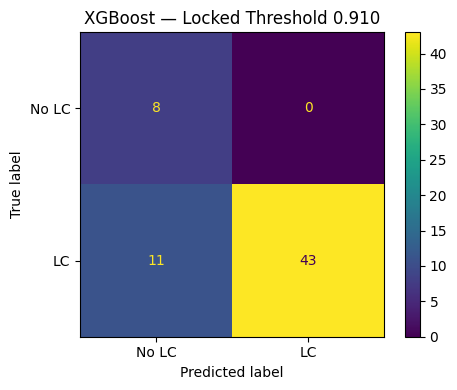

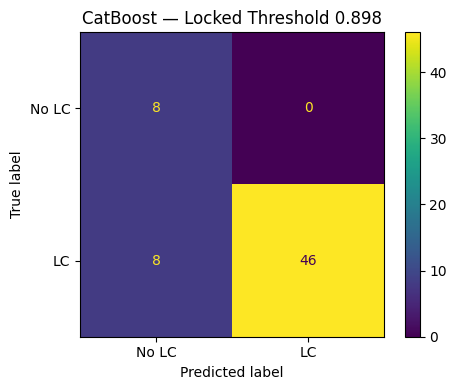

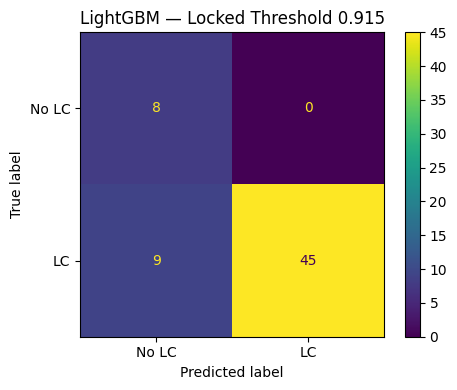

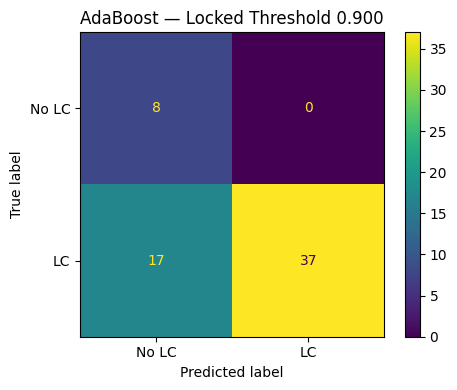

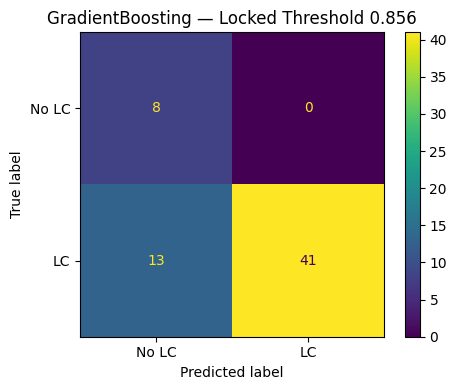

In [11]:
for name, stored in prediction_store.items():
    fig, ax = plt.subplots(figsize=(5,4))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        stored["pred_locked"],
        labels=[0,1],
        display_labels=["No LC", "LC"],
        values_format="d",
        ax=ax
    )

    ax.set_title(
        f"{name} — Locked Threshold {locked_thresholds[name]:.3f}"
    )

    plt.tight_layout()
    plt.savefig(
        f"LC_V2_CM_{name}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


## 11. ROC curves from predicted probabilities

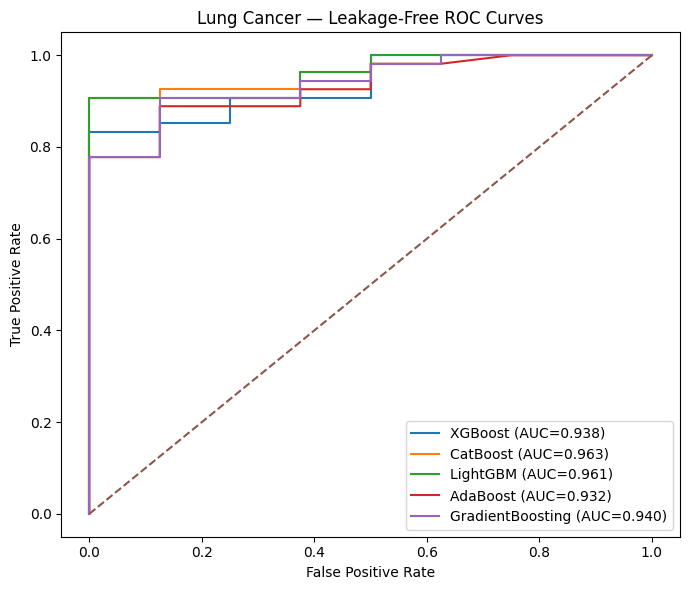

In [12]:
fig, ax = plt.subplots(figsize=(7,6))

for name, stored in prediction_store.items():
    fpr, tpr, _ = roc_curve(y_test, stored["prob"])
    auc_value = roc_auc_score(y_test, stored["prob"])

    ax.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_value:.3f})"
    )

ax.plot([0,1],[0,1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Lung Cancer — Leakage-Free ROC Curves")
ax.legend()

plt.tight_layout()
plt.savefig("LC_V2_ROC.png", dpi=300, bbox_inches="tight")
plt.show()


## 12. Precision–Recall curves

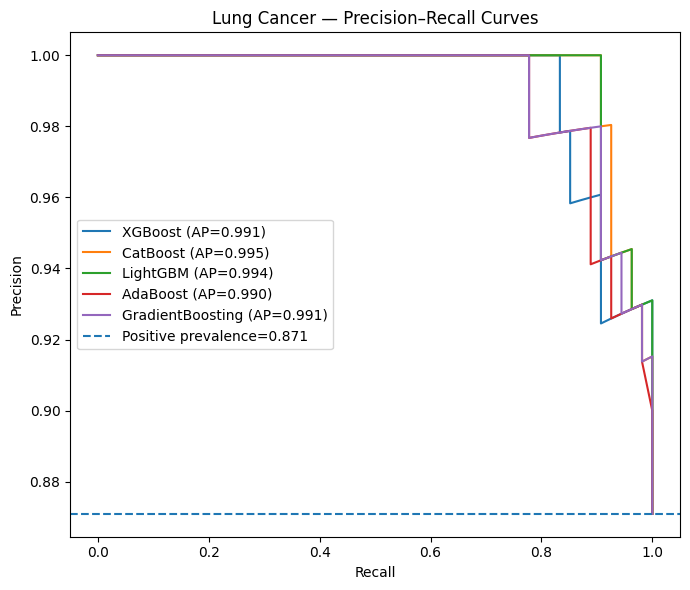

In [13]:
fig, ax = plt.subplots(figsize=(7,6))

for name, stored in prediction_store.items():
    precision, recall, _ = precision_recall_curve(
        y_test, stored["prob"]
    )

    ap = average_precision_score(
        y_test, stored["prob"]
    )

    ax.plot(
        recall,
        precision,
        label=f"{name} (AP={ap:.3f})"
    )

baseline = y_test.mean()
ax.axhline(
    baseline,
    linestyle="--",
    label=f"Positive prevalence={baseline:.3f}"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Lung Cancer — Precision–Recall Curves")
ax.legend()

plt.tight_layout()
plt.savefig("LC_V2_PR.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Calibration curves and Brier scores

With only ~62 held-out observations, calibration curves are exploratory and should be interpreted with caution. Brier score is also reported quantitatively.


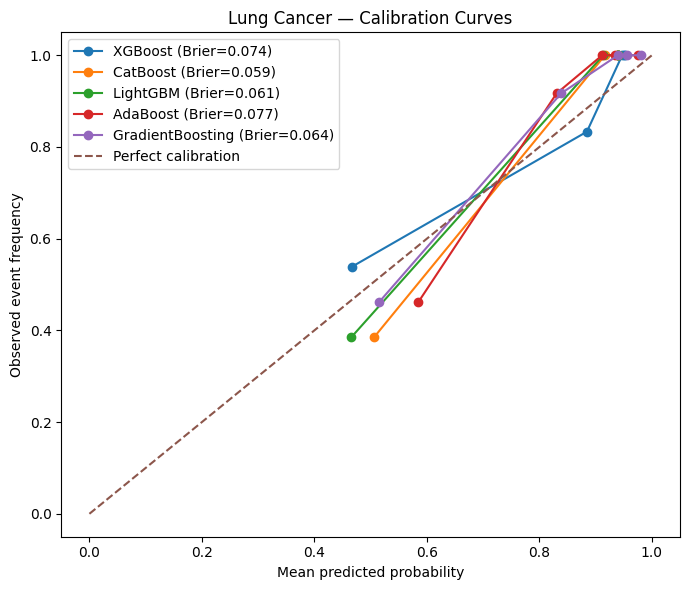

In [14]:
fig, ax = plt.subplots(figsize=(7,6))

for name, stored in prediction_store.items():
    frac_pos, mean_pred = calibration_curve(
        y_test,
        stored["prob"],
        n_bins=5,
        strategy="quantile"
    )

    brier = brier_score_loss(
        y_test,
        stored["prob"]
    )

    ax.plot(
        mean_pred,
        frac_pos,
        marker="o",
        label=f"{name} (Brier={brier:.3f})"
    )

ax.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Perfect calibration"
)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed event frequency")
ax.set_title("Lung Cancer — Calibration Curves")
ax.legend()

plt.tight_layout()
plt.savefig(
    "LC_V2_Calibration.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 14. Repeated stratified cross-validation for statistical testing

The repeated observations used for statistical analysis are **matched CV splits**, not different evaluation metrics.

This notebook uses 5 folds × 5 repeats = 25 matched observations for each model. The same split structure is used for all algorithms.


In [15]:
outer_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

cv_rows = []

for name, estimator in best_estimators.items():
    print("Repeated CV:", name)

    scores = cross_validate(
        clone(estimator),
        X, y,
        cv=outer_cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    for split_id in range(len(scores["test_f1"])):
        cv_rows.append({
            "Model": name,
            "Split": split_id + 1,
            "Accuracy": scores["test_accuracy"][split_id],
            "Balanced_Accuracy": scores["test_balanced_accuracy"][split_id],
            "Precision": scores["test_precision"][split_id],
            "Sensitivity": scores["test_recall"][split_id],
            "F1": scores["test_f1"][split_id],
            "ROC_AUC": scores["test_roc_auc"][split_id],
            "PR_AUC": scores["test_average_precision"][split_id]
        })

cv_df = pd.DataFrame(cv_rows)

cv_summary = cv_df.groupby("Model")[
    [
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Sensitivity",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
].agg(["mean","std"])

display(cv_summary)

cv_df.to_csv(
    "LC_V2_repeated_CV_scores.csv",
    index=False
)

cv_summary.to_csv(
    "LC_V2_repeated_CV_summary.csv"
)


Repeated CV: XGBoost
Repeated CV: CatBoost
Repeated CV: LightGBM
Repeated CV: AdaBoost
Repeated CV: GradientBoosting


Accuracy           Balanced_Accuracy           Precision  \
                      mean       std              mean       std      mean   
Model                                                                        
AdaBoost          0.848525  0.064912          0.816429  0.113364  0.963100   
CatBoost          0.897726  0.028827          0.761865  0.090122  0.939947   
GradientBoosting  0.886071  0.055347          0.842169  0.099328  0.966264   
LightGBM          0.896457  0.041266          0.771772  0.092745  0.942853   
XGBoost           0.891941  0.037605          0.773439  0.082578  0.943733   

                           Sensitivity                  F1            \
                       std        mean       std      mean       std   
Model                                                                  
AdaBoost          0.032558    0.860000  0.061205  0.907572  0.041626   
CatBoost          0.026378    0.944444  0.033385  0.941544  0.017059   
GradientBoosting  0.027579    0.901481  0.053115  0.931947  0.034828   
LightGBM          0.026500    0.939259  0.042606  0.940346  0.024782   
XGBoost           0.023770    0.932593  0.039603  0.937528  0.022790   

                   ROC_AUC              PR_AUC            
                      mean       std      mean       std  
Model                                                     
AdaBoost          0.903175  0.075343  0.984448  0.013117  
CatBoost          0.891283  0.069083  0.978923  0.018600  
GradientBoosting  0.931230  0.053502  0.989694  0.008455  
LightGBM          0.884471  0.081347  0.977493  0.021833  
XGBoost           0.899683  0.069288  0.981676  0.016541

## 15. Select the model for XAI using training-only evidence

The XAI model is selected using the **training-only OOF balanced accuracy**, with OOF ROC–AUC used as a tie-breaker. The held-out test set is not used for model selection.


In [16]:
xai_model_name = threshold_df.sort_values(
    ["OOF_Balanced_Accuracy", "OOF_ROC_AUC"],
    ascending=False
).iloc[0]["Model"]

print(
    "XAI model selected from training-only evidence:",
    xai_model_name
)

xai_pipeline = clone(best_estimators[xai_model_name])
xai_pipeline.fit(X_train, y_train)

imputer = xai_pipeline.named_steps["imputer"]
scaler = xai_pipeline.named_steps["scaler"]
base_model = xai_pipeline.named_steps["model"]

X_train_imp = imputer.transform(X_train)
X_test_imp = imputer.transform(X_test)

X_train_trans = scaler.transform(X_train_imp)
X_test_trans = scaler.transform(X_test_imp)

feature_names = list(X.columns)

X_train_trans_df = pd.DataFrame(
    X_train_trans,
    columns=feature_names,
    index=X_train.index
)

X_test_trans_df = pd.DataFrame(
    X_test_trans,
    columns=feature_names,
    index=X_test.index
)

print("Underlying XAI estimator:", type(base_model))


XAI model selected from training-only evidence: CatBoost
Underlying XAI estimator: <class 'catboost.core.CatBoostClassifier'>


## 16. SHAP global explanation — model-aware implementation

TreeExplainer is used for directly supported tree-based estimators.  
A model-agnostic permutation explainer is used for AdaBoost or any unsupported estimator.

The explainer background comes from the **training data only**.


Using SHAP TreeExplainer


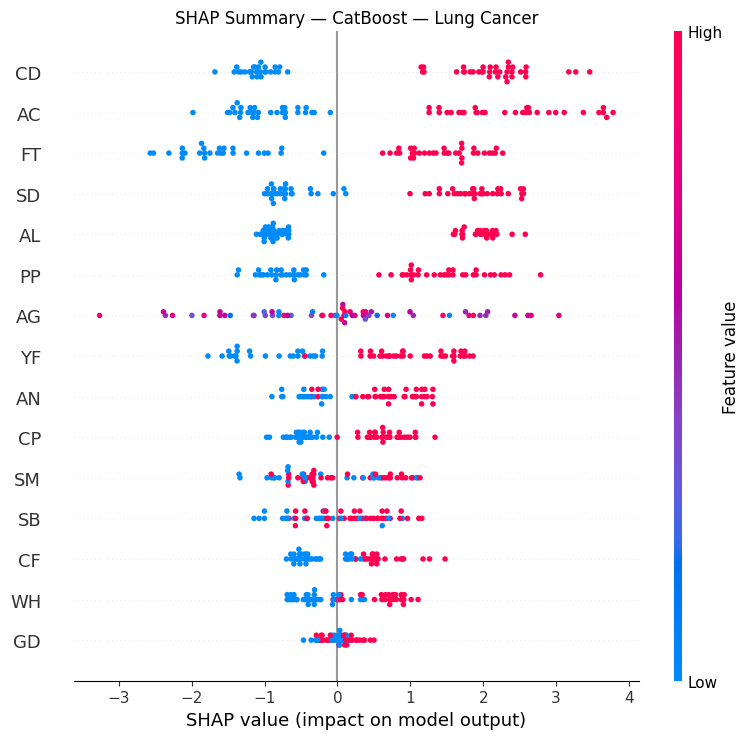

In [17]:
import shap

tree_supported = xai_model_name in [
    "XGBoost",
    "CatBoost",
    "LightGBM",
    "GradientBoosting"
]

if tree_supported:
    print("Using SHAP TreeExplainer")

    explainer = shap.TreeExplainer(base_model)
    shap_values = explainer.shap_values(X_test_trans_df)

    if isinstance(shap_values, list):
        shap_for_plot = shap_values[-1]
    else:
        shap_for_plot = shap_values

    shap_exp = None

else:
    print("Using model-agnostic SHAP permutation explainer")

    background = shap.sample(
        X_train_trans_df,
        min(100, len(X_train_trans_df)),
        random_state=RANDOM_STATE
    )

    def predict_positive_probability(X_input):
        arr = (
            X_input.values
            if isinstance(X_input, pd.DataFrame)
            else np.asarray(X_input)
        )
        return base_model.predict_proba(arr)[:,1]

    explainer = shap.Explainer(
        predict_positive_probability,
        background,
        algorithm="permutation"
    )

    shap_exp = explainer(
        X_test_trans_df,
        max_evals=2 * X_test_trans_df.shape[1] + 1
    )

    shap_for_plot = shap_exp.values

# Normalize possible dimensionality
shap_array = np.asarray(shap_for_plot)

if shap_array.ndim == 3:
    shap_array = shap_array[:, :, -1]

shap.summary_plot(
    shap_array,
    X_test_trans_df,
    feature_names=feature_names,
    show=False
)

plt.title(
    f"SHAP Summary — {xai_model_name} — Lung Cancer"
)

plt.tight_layout()
plt.savefig(
    "LC_V2_SHAP_summary.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 17. SHAP global mean absolute importance

,Feature,Mean_Absolute_SHAP
6,CD,1.706871
10,AC,1.693086
7,FT,1.526208
13,SD,1.354585
8,AL,1.350273
5,PP,1.162226
1,AG,1.042031
3,YF,1.036800
4,AN,0.645792
14,CP,0.599817


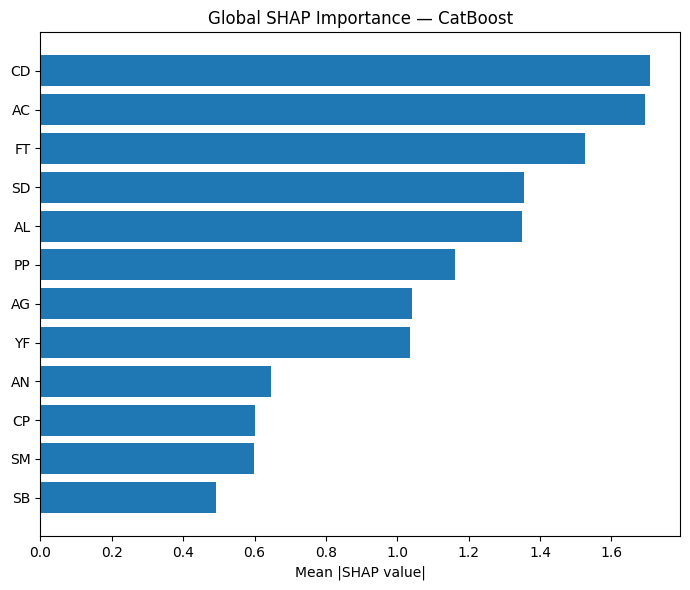

In [18]:
mean_abs_shap = np.abs(shap_array).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

display(shap_importance_df)

shap_importance_df.to_csv(
    "LC_V2_SHAP_global_importance.csv",
    index=False
)

top = (
    shap_importance_df
    .head(12)
    .sort_values("Mean_Absolute_SHAP")
)

plt.figure(figsize=(7,6))
plt.barh(
    top["Feature"],
    top["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean |SHAP value|")
plt.title(
    f"Global SHAP Importance — {xai_model_name}"
)

plt.tight_layout()
plt.savefig(
    "LC_V2_SHAP_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 18. Representative held-out test cases for local XAI

Representative positive and negative cases are chosen **algorithmically**, not manually:
- the case must preferably be correctly classified;
- among eligible cases, the observation with calibrated probability closest to the median probability of that true class is selected.

This avoids deliberately selecting extreme 0.00/1.00 examples.


In [19]:
# Use the calibrated selected model for case-selection probabilities.
selected_calibrated = calibrated_models[xai_model_name]
selected_prob = selected_calibrated.predict_proba(X_test)[:,1]

selected_threshold = locked_thresholds[xai_model_name]
selected_pred = (
    selected_prob >= selected_threshold
).astype(int)

y_test_array = y_test.to_numpy()

def representative_index(target_class):
    candidates = np.where(
        (y_test_array == target_class) &
        (selected_pred == target_class)
    )[0]

    # If there is no correctly classified case of that class,
    # fall back to any observation from the class.
    if len(candidates) == 0:
        candidates = np.where(
            y_test_array == target_class
        )[0]

    probs = selected_prob[candidates]
    median_prob = np.median(probs)

    return int(
        candidates[
            np.argmin(
                np.abs(probs - median_prob)
            )
        ]
    )

rep_neg = representative_index(0)
rep_pos = representative_index(1)

print(
    "Representative No-LC case:",
    rep_neg,
    "calibrated P(LC)=",
    round(selected_prob[rep_neg], 4)
)

print(
    "Representative LC case:",
    rep_pos,
    "calibrated P(LC)=",
    round(selected_prob[rep_pos], 4)
)


Representative No-LC case: 6 calibrated P(LC)= 0.5273
Representative LC case: 2 calibrated P(LC)= 0.9398


## 19. Representative SHAP waterfall explanations

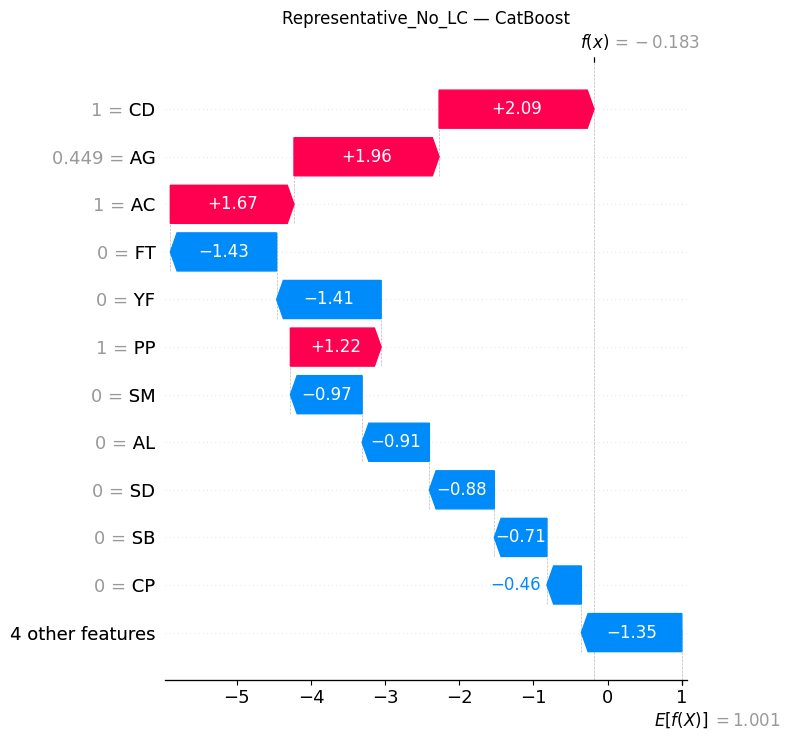

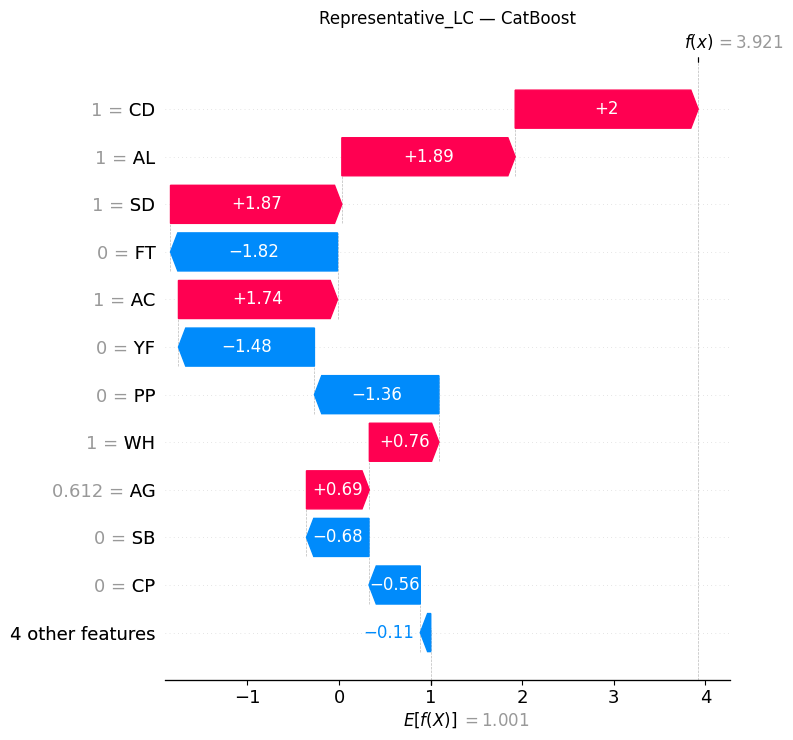

In [20]:
if tree_supported:
    expected = explainer.expected_value

    if isinstance(expected, (list, np.ndarray)):
        expected_value = np.asarray(expected).ravel()[-1]
    else:
        expected_value = expected

for label, pos in [
    ("Representative_No_LC", rep_neg),
    ("Representative_LC", rep_pos)
]:

    if not tree_supported:
        case_exp = shap_exp[pos]

    else:
        case_exp = shap.Explanation(
            values=shap_array[pos],
            base_values=expected_value,
            data=X_test_trans_df.iloc[pos].values,
            feature_names=feature_names
        )

    shap.plots.waterfall(
        case_exp,
        max_display=12,
        show=False
    )

    plt.title(
        f"{label} — {xai_model_name}"
    )

    plt.tight_layout()
    plt.savefig(
        f"LC_V2_SHAP_{label}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


## 20. LIME representative local explanations

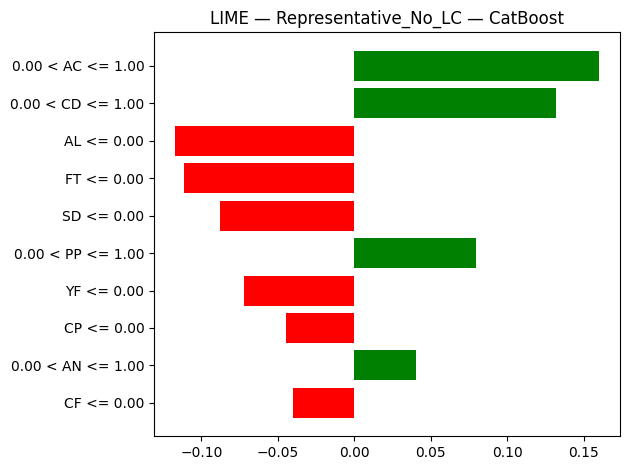

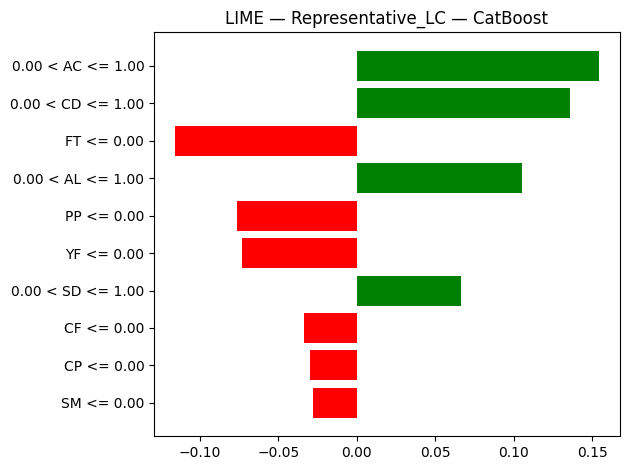

,Case,Rule,Weight
0,Representative_No_LC,0.00 < AC <= 1.00,0.159908
1,Representative_No_LC,0.00 < CD <= 1.00,0.131904
2,Representative_No_LC,AL <= 0.00,-0.117142
3,Representative_No_LC,FT <= 0.00,-0.111563
4,Representative_No_LC,SD <= 0.00,-0.087601
5,Representative_No_LC,0.00 < PP <= 1.00,0.079761
6,Representative_No_LC,YF <= 0.00,-0.071870
7,Representative_No_LC,CP <= 0.00,-0.044438
8,Representative_No_LC,0.00 < AN <= 1.00,0.040292
9,Representative_No_LC,CF <= 0.00,-0.039960


In [21]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_trans_df.to_numpy(),
    feature_names=feature_names,
    class_names=[
        "No Lung Cancer",
        "Lung Cancer"
    ],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

def lime_predict_fn(arr):
    return base_model.predict_proba(arr)

lime_rows = []

for label, pos in [
    ("Representative_No_LC", rep_neg),
    ("Representative_LC", rep_pos)
]:

    exp = lime_explainer.explain_instance(
        X_test_trans_df.iloc[pos].to_numpy(),
        lime_predict_fn,
        num_features=min(10, len(feature_names))
    )

    fig = exp.as_pyplot_figure()
    plt.title(
        f"LIME — {label} — {xai_model_name}"
    )

    plt.tight_layout()
    plt.savefig(
        f"LC_V2_LIME_{label}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    for rule, weight in exp.as_list():
        lime_rows.append({
            "Case": label,
            "Rule": rule,
            "Weight": weight
        })

lime_df = pd.DataFrame(lime_rows)
display(lime_df)

lime_df.to_csv(
    "LC_V2_LIME_representative_cases.csv",
    index=False
)


## 21. Manuscript-ready summary table

The table below reports results obtained using the **training-derived locked threshold**.  
For this small and imbalanced dataset, balanced accuracy, sensitivity, specificity, ROC–AUC, PR–AUC, and calibration should be interpreted alongside raw accuracy.


In [22]:
manuscript_table = (
    test_results_df[
        test_results_df["Threshold_Type"] ==
        "Training_Optimized"
    ][[
        "Model",
        "Threshold",
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1",
        "ROC_AUC",
        "PR_AUC",
        "Brier"
    ]]
    .copy()
)

percentage_columns = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]

for col in percentage_columns:
    manuscript_table[col] = (
        100 * manuscript_table[col]
    ).round(2)

manuscript_table["Threshold"] = (
    manuscript_table["Threshold"].round(4)
)

manuscript_table["Brier"] = (
    manuscript_table["Brier"].round(4)
)

display(manuscript_table)

manuscript_table.to_csv(
    "LC_V2_manuscript_summary_table.csv",
    index=False
)


,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC,Brier
1,XGBoost,0.9103,82.26,89.81,100.0,79.63,100.0,88.66,93.75,99.08,0.0737
3,CatBoost,0.8985,87.10,92.59,100.0,85.19,100.0,92.00,96.30,99.47,0.0593
5,LightGBM,0.9148,85.48,91.67,100.0,83.33,100.0,90.91,96.06,99.43,0.0612
7,AdaBoost,0.9001,72.58,84.26,100.0,68.52,100.0,81.32,93.17,98.97,0.0766
9,GradientBoosting,0.8561,79.03,87.96,100.0,75.93,100.0,86.32,93.98,99.10,0.0640


## 22. Revision outputs to retain

### Numerical files
- `LC_V2_hyperparameters.csv`
- `LC_V2_training_only_thresholds.csv`
- `LC_V2_test_results_default_and_optimized.csv`
- `LC_V2_results_with_95CI.csv`
- `LC_V2_repeated_CV_scores.csv`
- `LC_V2_repeated_CV_summary.csv`
- `LC_V2_manuscript_summary_table.csv`
- `LC_V2_SHAP_global_importance.csv`
- `LC_V2_LIME_representative_cases.csv`

### Figures
- model-specific confusion matrices
- `LC_V2_ROC.png`
- `LC_V2_PR.png`
- `LC_V2_Calibration.png`
- `LC_V2_SHAP_summary.png`
- `LC_V2_SHAP_importance.png`
- representative SHAP waterfalls
- representative LIME explanations

### Interpretation cautions
1. Do not compare the revised accuracy directly with the original 98.90% as though both estimates were obtained under the same validation protocol.
2. Do not describe the symptom-based public dataset as a clinically validated diagnostic cohort.
3. Do not describe SHAP/LIME feature contributions as causal risk factors.
4. Extreme prediction probabilities, if observed, are model outputs rather than clinical certainty.
5. Because the held-out negative class is very small, specificity and calibration estimates should be reported with uncertainty.
